In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv("converted (1).csv")

In [4]:
print("Dataset:")
print(df)

Dataset:
    CustomerID  Age  AnnualIncome  SpendingScore
0            1   19         15000             39
1            2   21         15000             81
2            3   20         16000              6
3            4   23         16000             77
4            5   31         17000             40
5            6   22         18000             76
6            7   35         18000              6
7            8   23         19000             94
8            9   64         20000              3
9           10   30         20000             72
10          11   67         25000             14
11          12   35         25000             99
12          13   58         27000             15
13          14   24         28000             77
14          15   37         29000             13
15          16   22         30000             79
16          17   35         30000             35
17          18   20         32000             66
18          19   52         33000             29
19         

In [5]:
print("\nFirst Five Records:")
print(df.head())


First Five Records:
   CustomerID  Age  AnnualIncome  SpendingScore
0           1   19         15000             39
1           2   21         15000             81
2           3   20         16000              6
3           4   23         16000             77
4           5   31         17000             40


In [6]:
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CustomerID     40 non-null     int64
 1   Age            40 non-null     int64
 2   AnnualIncome   40 non-null     int64
 3   SpendingScore  40 non-null     int64
dtypes: int64(4)
memory usage: 1.4 KB
None


In [7]:
X = df[["AnnualIncome", "SpendingScore"]]

In [8]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

In [9]:
kmeans.fit(X)

C:\Users\alshifa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [10]:
df["Cluster"] = kmeans.labels_

In [11]:
print("\nClustered Dataset:")
print(df)


Clustered Dataset:
    CustomerID  Age  AnnualIncome  SpendingScore  Cluster
0            1   19         15000             39        2
1            2   21         15000             81        2
2            3   20         16000              6        2
3            4   23         16000             77        2
4            5   31         17000             40        2
5            6   22         18000             76        2
6            7   35         18000              6        2
7            8   23         19000             94        2
8            9   64         20000              3        2
9           10   30         20000             72        2
10          11   67         25000             14        2
11          12   35         25000             99        2
12          13   58         27000             15        0
13          14   24         28000             77        0
14          15   37         29000             13        0
15          16   22         30000             79    

In [12]:
print("\nCluster Centroids:")
print(kmeans.cluster_centers_)


Cluster Centroids:
[[3.37500000e+04 4.91875000e+01]
 [4.85000000e+04 4.80000000e+01]
 [1.86666667e+04 5.05833333e+01]]


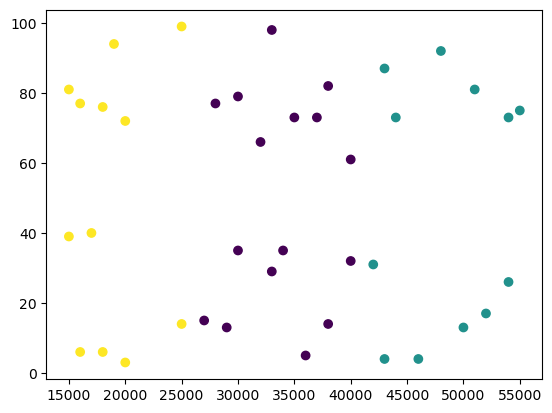

In [13]:
plt.scatter(
    df["AnnualIncome"],
    df["SpendingScore"],
    c=df["Cluster"]
)

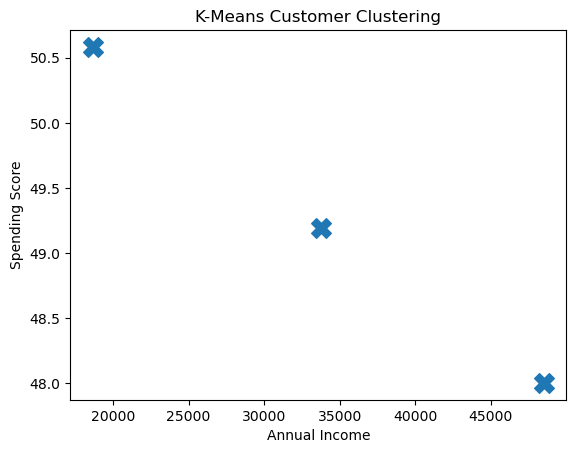

In [14]:
centers = kmeans.cluster_centers_
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=200
)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("K-Means Customer Clustering")
plt.show()